# Diffusion-TS Tutorial

## Diffusion-TS: Interpretable Diffusion for General Time Series Generation

This notebook describes the user-guide of a time-series synthetic data generation application using Diffusion-TS framework.

## Necessary packages and functions call

In [1]:
import os
import torch
import numpy as np

from engine.solver import Trainer
from Utils.metric_utils import visualization
from Data.build_dataloader import build_dataloader
from Utils.io_utils import load_yaml_config, instantiate_from_config
from Models.interpretable_diffusion.model_utils import unnormalize_to_zero_to_one

/home/stelios-pc/anaconda3/envs/Diffusion/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setting and Training

### Build dataset and settings

In [2]:
class Args_Example:
    def __init__(self) -> None:
        self.config_path = './Config/energy.yaml'
        self.save_dir = './energy_results/ETTh1'
        self.gpu = 0
        os.makedirs(self.save_dir, exist_ok=True)

args =  Args_Example()
configs = load_yaml_config(args.config_path)
device = torch.device(f'cuda:{args.gpu}' if torch.cuda.is_available() else 'cpu')

dl_info = build_dataloader(configs, args)
model = instantiate_from_config(configs['model']).to(device)
trainer = Trainer(config=configs, args=args, model=model, dataloader=dl_info)

### Training models

In [3]:
trainer.train()

loss: 0.105045: 100%|██████████| 25000/25000 [29:30<00:00, 14.12it/s]

training complete


## Inference and Visualizations

### Sampling

In [ ]:
dataset = dl_info['dataset']
seq_length, feature_dim = dataset.window, dataset.var_num
# ori_data = np.load(os.path.join(dataset.dir, f"sine_ground_truth_{seq_length}_train.npy"))
ori_data = np.load(os.path.join(dataset.dir, f"ETTh1_norm_truth_{seq_length}_train.npy"))  # Uncomment the line if dataset other than Sine is used.
# test_data = np.load(os.path.join(dataset.dir, f"energy_norm_truth_{seq_length}_test.npy"))
fake_data = trainer.sample(num=len(dataset), size_every=512, shape=[seq_length, feature_dim])

sampling loop time step: 100%|██████████| 1000/1000 [01:34<00:00, 10.58it/s]


In [5]:
if dataset.auto_norm:
    # np.save(os.path.join(args.save_dir, f'ddpm_fake_energy_negative1_to1.npy'), fake_data)
    fake_data = unnormalize_to_zero_to_one(fake_data)
    np.save(os.path.join(args.save_dir, f'ddpm_fake_energy_0_to_1'), fake_data)
    raw_data = dataset.scaler.inverse_transform(fake_data.reshape(-1, fake_data.shape[-1]))
    raw_data = raw_data.reshape(fake_data.shape)
    print(raw_data.shape)
    np.save(os.path.join(args.save_dir, f'ETTh1_ddpm_fake_energy_raw'), raw_data)

(14848, 169, 13)


### Visualization

We visualize the original and synthetic data distributions using PCA, tSNE and Density analysis.

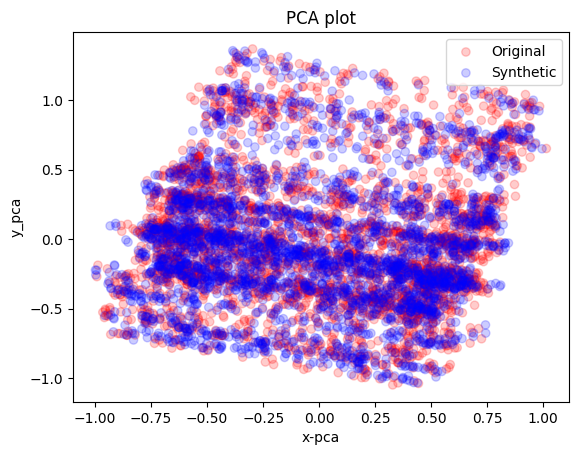

In [ ]:
# visualization(ori_data=ori_data, generated_data=fake_data, analysis='pca', compare=ori_data.shape[0])
visualization(ori_data=ori_data, generated_data=fake_data, analysis='pca', dataset_name='ETTh1_pca_plot', compare=3000)

/home/stelios-pc/anaconda3/envs/Diffusion/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/stelios-pc/anaconda3/envs/Diffusion/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 6000 samples in 0.000s...
[t-SNE] Computed neighbors for 6000 samples in 0.266s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6000
[t-SNE] Computed conditional probabilities for sample 2000 / 6000
[t-SNE] Computed conditional probabilities for sample 3000 / 6000
[t-SNE] Computed conditional probabilities for sample 4000 / 6000
[t-SNE] Computed conditional probabilities for sample 5000 / 6000
[t-SNE] Computed conditional probabilities for sample 6000 / 6000
[t-SNE] Mean sigma: 0.236814
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.736404
[t-SNE] KL divergence after 300 iterations: 2.305063


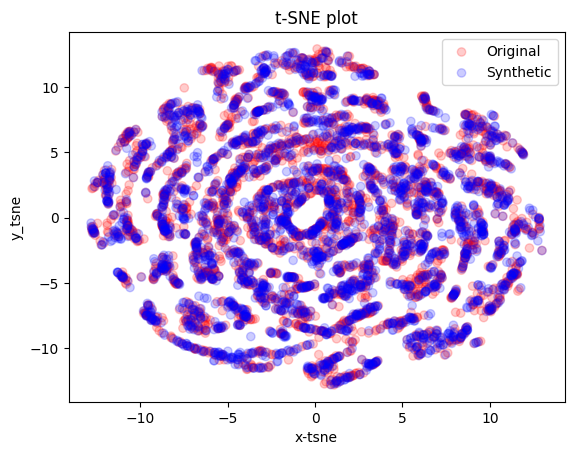

In [ ]:
visualization(ori_data=ori_data, generated_data=fake_data, analysis='tsne', dataset_name='ETTh1_tsne_plot', compare=3000)

/home/stelios-pc/Desktop/PhD/Paper/tSDG-DiffusionTS-DataAugmentation/Diffusion-TS/Utils/metric_utils.py:159: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(prep_data, hist=False, kde=True, kde_kws={'linewidth': 5}, label='Original', color="red")
/home/stelios-pc/Desktop/PhD/Paper/tSDG-DiffusionTS-DataAugmentation/Diffusion-TS/Utils/metric_utils.py:160: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your c

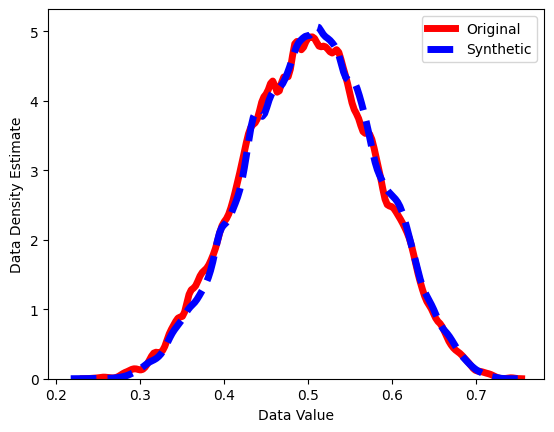

In [ ]:
visualization(ori_data=ori_data, generated_data=fake_data, analysis='kernel', dataset_name='ETTh1_kernel_density_plot', compare=ori_data.shape[0])